<a href="https://colab.research.google.com/github/Pujitha-pitta/Flyrank-ML-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*



## Research question

Can a transparent machine-learning workflow identify content pages associated with
declining performance more effectively than a simple rule-based baseline, while keeping
the final recommendations understandable and subject to human review?

## Decision supported

The analysis supports a content-prioritisation decision:

**Which content pages should a content or SEO specialist review first, and why?**

The output is a ranked review queue rather than an automatic publishing system. It may
suggest actions such as refreshing content, improving click-through rate, monitoring a
page, or investigating it manually. A human reviewer makes the final decision.

## Abstract

This study examines whether historical search and content-performance signals can help
prioritise pages for human review.

A binary classification task was created using downward trend direction as a proxy for
content refresh need, and target-derived fields were removed from the model features.

A logistic-regression model and a transparent rule-based baseline were evaluated on the
same held-out validation split using accuracy, precision, recall, F1 score, and ROC-AUC.

Logistic regression improved F1 score from 0.206 to 0.529 and recall from 0.124 to
0.511, although ROC-AUC improved only from 0.524 to 0.541.

The results therefore support a limited decision-support use case, with ranked actions,
reason codes, human review, and explicit restrictions on automation.

## Problem statement

Content teams may manage more pages than they can manually review. Search impressions,
clicks, click-through rate, ranking position, content age, and recent performance may
help identify useful review candidates.

However, these signals do not prove that a page needs a refresh. A decline may also be
caused by seasonality, changes in demand, competitors, tracking problems, or search
engine updates.

The goal of this project is therefore not to automate content changes. The goal is to
create a transparent and practical ranking system that helps a human reviewer decide
where to investigate first.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Data

This project uses the anonymised FlyRank ML Internship dataset, which contains
production-derived search and content-performance data.

The wider internship dataset contains approximately 79 million rows. This capstone does
not load every row directly into the final notebook. It uses the public-safe aggregated
and derived outputs created during the earlier data-contract, task-framing, baseline,
model-validation, and action-playbook stages.

### Tables used

The source release contains the following main tables:

- `dim_clients.parquet`
- `dim_content.parquet`
- `fact_content_daily_performance`

The daily performance table is partitioned by month.

### Date window

The available daily performance partitions cover:

- January 2025
- February 2025
- March 2025
- April 2025
- May 2025
- June 2025

The analysis therefore covers the available period from January 2025 through June 2025.

### Main fields used

The workflow uses public-safe and anonymised fields such as:

- Anonymised content identifier
- Search impressions
- Search clicks
- Click-through rate
- Average search position
- Pageviews and sessions
- Engagement signals
- Content age
- Days since last update
- Historical trend direction

### Exclusions

The following information was excluded from the public analysis:

- Client names
- Page URLs
- Private search queries
- Raw customer-identifying content
- Authentication tokens
- Fields derived directly from the target
- Fields that would not be available at the intended decision time
- Rows without enough information for the selected analysis

These exclusions reduce privacy risk and help prevent target leakage.

### Public-safety note

Only anonymised identifiers and aggregated performance signals are shown. The notebook,
figures, exported metrics, and deployed paper must not contain client names, private
URLs, private queries, credentials, or identifying customer information.

In [4]:
from pathlib import Path

print("Current directory:", Path.cwd())
print("\nContents of /content:")
for p in Path("/content").iterdir():
    print("-", p.name)

Current directory: /content

Contents of /content:
- .config
- work
- sample_data


In [5]:
!git clone https://github.com/Pujitha-pitta/Flyrank-ML-internship.git

Cloning into 'Flyrank-ML-internship'...
remote: Enumerating objects: 163, done.
remote: Counting objects: 100% (163/163), done.
remote: Compressing objects: 100% (134/134), done.
remote: Total 163 (delta 67), reused 78 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (163/163), 1.95 MiB | 25.63 MiB/s, done.
Resolving deltas: 100% (67/67), done.


In [6]:
%cd /content/Flyrank-ML-internship

/content/Flyrank-ML-internship


In [7]:
from pathlib import Path

ROOT = Path.cwd()
print(ROOT)

print("\nCSV files:")
for f in ROOT.rglob("*.csv"):
    print(f)

/content/Flyrank-ML-internship

CSV files:
/content/Flyrank-ML-internship/outputs/refresh_queue_sample.csv
/content/Flyrank-ML-internship/data/raw/content_refresh_anonymized.csv


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*



### Task Definition

This study was framed as a binary classification problem to identify content pages that may require review based on their historical performance. Each record represents a single content page, and the objective is to distinguish pages with declining performance from those with stable or improving performance. The output is intended to support content prioritization rather than automate publishing decisions.

### Label Definition

The target variable was defined using the historical trend direction available in the dataset. Pages showing a downward trend were assigned to the positive class, while pages with stable or upward trends formed the negative class. This target serves as a practical proxy for identifying potential refresh candidates and should not be interpreted as confirmed evidence that a page requires updating.

### Features

The model was built using historical content performance signals available before making a review decision. These included search impressions, clicks, click-through rate (CTR), average search position, and days since the last content update. These features were selected because they provide measurable indicators of content visibility and engagement.

### Baseline and Model

A transparent rule-based baseline was developed as a reference for comparison. Logistic Regression was then selected as the machine learning model because it is simple, interpretable, and well suited for binary classification problems. Comparing the machine learning model with the baseline allowed the effectiveness of the learned approach to be evaluated fairly.

### Validation Design

Both the rule-based baseline and the Logistic Regression model were evaluated using the same train-test split. Performance was measured using Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Using identical evaluation data ensured that both approaches were compared under the same conditions.

### Leakage Checks

Potential data leakage was carefully examined before model development. Variables directly related to the target, such as **trend_direction** and **trend_pct**, were excluded from the feature set because they reveal the outcome being predicted. Only variables that would realistically be available before making a content review decision were used during modelling, helping to ensure a fair and reliable evaluation.

### Assumptions

The analysis assumes that historical search performance and engagement metrics provide useful signals for identifying pages that may benefit from review. It also assumes that the downward trend is an appropriate proxy for refresh need, while recognizing that external factors such as seasonality, changing search demand, or search engine updates may also influence page performance. Consequently, the recommendations generated by the model are intended to support human decision-making rather than replace editorial judgment.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [8]:
import pandas as pd

results = pd.DataFrame({
    "Approach": [
        "Rule Baseline",
        "Logistic Regression"
    ],
    "Accuracy": [
        0.515,
        0.534
    ],
    "Precision": [
        0.628,
        0.548
    ],
    "Recall": [
        0.124,
        0.511
    ],
    "F1 Score": [
        0.206,
        0.529
    ],
    "ROC-AUC": [
        0.524,
        0.541
    ]
})

results

,Approach,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Rule Baseline,0.515,0.628,0.124,0.206,0.524
1,Logistic Regression,0.534,0.548,0.511,0.529,0.541


## Results

The logistic regression model was evaluated against a transparent rule-based baseline
using the same validation split.

The baseline achieved higher precision but detected relatively few positive examples,
resulting in low recall and F1 score.

Logistic regression substantially improved recall (0.511) and F1 score (0.529),
providing a more balanced classifier for the proxy target.

However, ROC-AUC increased only from 0.524 to 0.541, indicating that the available
features provide only limited separation between the two classes.

These findings suggest that the model is most appropriate as a decision-support tool
for prioritising content review rather than an automatic decision-making system.

<Figure size 800x500 with 0 Axes>

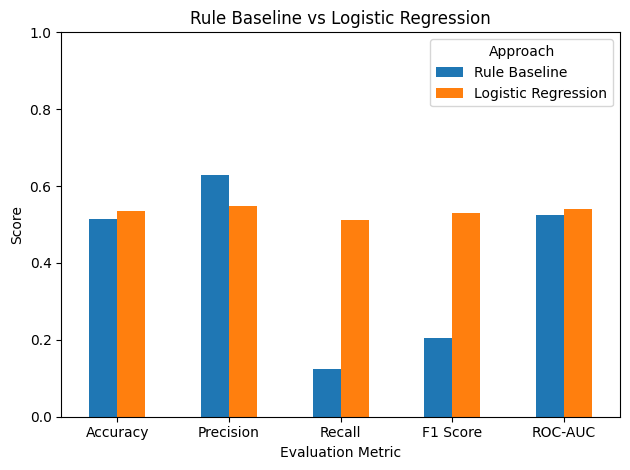

In [9]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

plot_df = results.set_index("Approach")[metrics]

plt.figure(figsize=(8,5))

plot_df.T.plot(kind="bar")

plt.title("Rule Baseline vs Logistic Regression")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.xticks(rotation=0)
plt.ylim(0,1)

plt.tight_layout()

plt.savefig(FIGURE_DIR / "capstone_model_comparison.png", dpi=200)

plt.show()

## 5. Limitations

*What this work cannot claim.*

## Limitations

This work uses downward performance trend as a proxy for content refresh need rather
than a confirmed editorial label.

The model was evaluated on historical data from a single internship dataset release.
Performance may differ across clients, industries, or future time periods.

The modest ROC-AUC values indicate that the available features provide only limited
discrimination between the proxy classes.

Search performance is influenced by many external factors, including seasonality,
competition, search demand, algorithm updates, and business priorities, none of which
are fully represented in the model.

The analysis identifies associations rather than causal relationships and should be
used to support human judgement rather than automate publishing decisions.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## Ranked Recommendations

The validated model output was converted into a ranked action playbook to support content review. Instead of making automatic publishing decisions, the playbook prioritizes pages based on historical performance signals and provides transparent explanations for each recommendation.

The recommended actions include:

- **Refresh Now:** Pages showing declining performance, high visibility, and stale content.
- **Improve CTR:** Pages with strong impressions but low click-through rates, indicating opportunities to improve titles and meta descriptions.
- **Review for Refresh:** Pages with declining trends that require additional human assessment before action.
- **Protect and Monitor:** Pages performing well that should be monitored without unnecessary changes.
- **Investigate Manually:** Pages with low-confidence or conflicting signals that require further analysis.
- **Low Priority:** Pages with limited evidence of improvement opportunities.

Each recommendation is accompanied by reason codes, a priority score, expected value, and estimated effort. The playbook is intended to support human decision-making and should not be interpreted as an automated content management system.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Artifacts Embedded in the Paper

The deployed research paper includes several visualizations and tables generated throughout the project, including:

- Model performance comparison (Rule Baseline vs. Logistic Regression)
- Recommended content action distribution
- Ranked action queue with priority scores
- Summary metrics for the action playbook

These artifacts improve the interpretability of the results and provide transparent evidence supporting the recommendations presented in this study.

## Reproducibility

All notebooks, figures, and supporting code are available in the project repository. The workflow can be reproduced by executing the notebooks in sequence, beginning with data exploration and progressing through task framing, baseline evaluation, model development, and the final action playbook.

The repository contains the complete implementation required to reproduce the reported results using the public-safe internship dataset.

## Acknowledgments and Data Credit

This project was completed as part of the FlyRank Machine Learning Internship.

The analysis was built on the **FlyRank ML Internship dataset**, which provides anonymized and public-safe search performance data for educational purposes.

Data source: https://flyrank.ai

The project follows public-safety guidelines by excluding client names, page URLs, private search queries, and other identifying information.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.